# Note: Verify the frame data definition

In [1]:
import numpy as np
import akshare as ak
import matplotlib.pyplot as plt
import pandas as pd

In [22]:
fund_open_fund_info_em_df_unit = ak.fund_open_fund_info_em(symbol="161606", indicator="单位净值走势")
fund_open_fund_info_em_df_cum = ak.fund_open_fund_info_em(symbol="161606", indicator="累计净值走势")
fund_open_fund_info_em_df_decomp = ak.fund_open_fund_info_em(symbol="161606", indicator="分红送配详情")

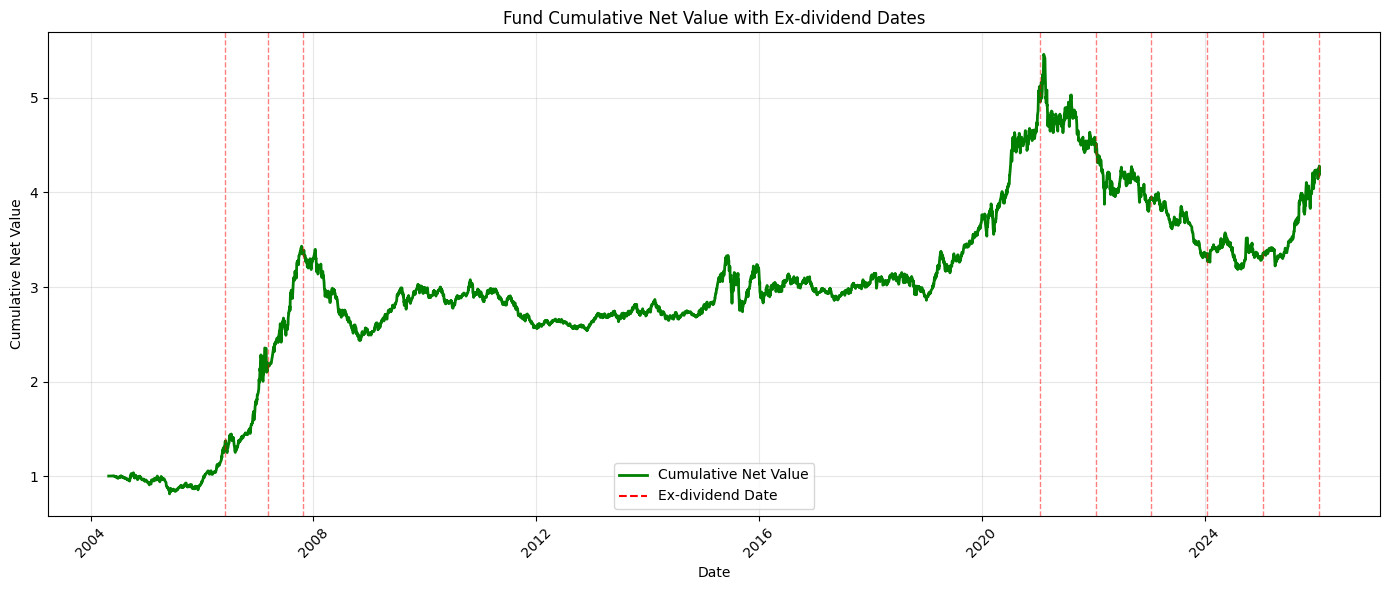

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 6))

# Convert dates to datetime for proper plotting
dates_cum = pd.to_datetime(fund_open_fund_info_em_df_cum['净值日期'])
cum_values = fund_open_fund_info_em_df_cum['累计净值'].values

dates_unit = pd.to_datetime(fund_open_fund_info_em_df_unit['净值日期'])
unit_values = fund_open_fund_info_em_df_unit['单位净值'].values

# Plot cumulative net value on left y-axis
color1 = 'green'
ax1.set_xlabel('Date')
ax1.set_ylabel('Cumulative Net Value', color=color1)
ax1.plot(dates_cum, cum_values, label='Cumulative Net Value', linewidth=2, color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

# Create second y-axis for unit net value
ax2 = ax1.twinx()
color2 = 'blue'
ax2.set_ylabel('Unit Net Value', color=color2)
ax2.plot(dates_unit, unit_values, label='Unit Net Value', linewidth=2, color=color2, linestyle=':')
ax2.tick_params(axis='y', labelcolor=color2)

# Mark dividend/distribution dates
if '除息日' in fund_open_fund_info_em_df_decomp.columns:
    ex_dividend_dates = pd.to_datetime(fund_open_fund_info_em_df_decomp['除息日'])
    for date in ex_dividend_dates:
        ax1.axvline(x=date, color='red', linestyle='--', alpha=0.5, linewidth=1)
    ax1.plot([], [], color='red', linestyle='--', label='Ex-dividend Date')

ax1.set_title('Fund Net Values with Ex-dividend Dates')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

fig.tight_layout()
plt.show()

/var/folders/1l/ngmgj5nj7bdfp6r1y9z7_vs00000gn/T/ipykernel_70607/1273062308.py:22: UserWarning: Glyph 38500 (\N{CJK UNIFIED IDEOGRAPH-9664}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/1l/ngmgj5nj7bdfp6r1y9z7_vs00000gn/T/ipykernel_70607/1273062308.py:22: UserWarning: Glyph 24687 (\N{CJK UNIFIED IDEOGRAPH-606F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/1l/ngmgj5nj7bdfp6r1y9z7_vs00000gn/T/ipykernel_70607/1273062308.py:22: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/yuliu/miniconda3/envs/ws/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 38500 (\N{CJK UNIFIED IDEOGRAPH-9664}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yuliu/miniconda3/envs/ws/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 24687 (\N{CJK UNIFIED IDEOGRAPH-606F}) missing from font(s) DejaVu Sans.
  

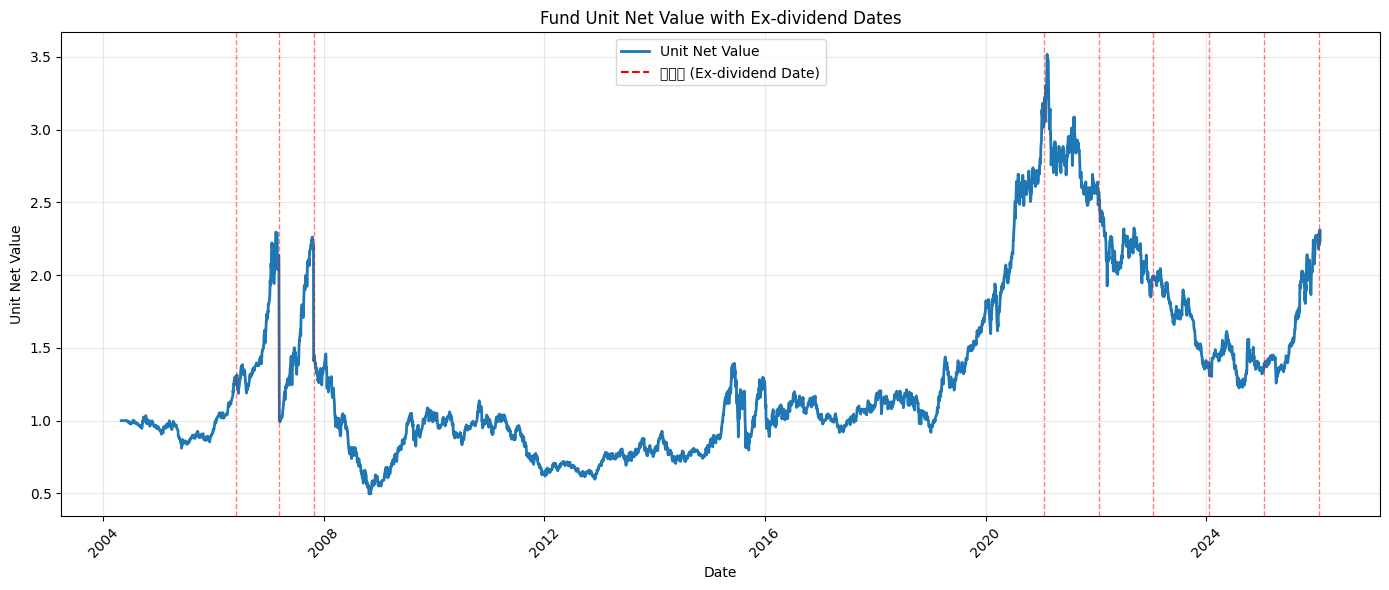

In [29]:
plt.figure(figsize=(14, 6))

# Convert dates to datetime for proper plotting
dates = pd.to_datetime(fund_open_fund_info_em_df_unit['净值日期'])
values = fund_open_fund_info_em_df_unit['单位净值'].values

plt.plot(dates, values, label='Unit Net Value', linewidth=2)

# Mark dividend/distribution dates
if '除息日' in fund_open_fund_info_em_df_decomp.columns:
    ex_dividend_dates = pd.to_datetime(fund_open_fund_info_em_df_decomp['除息日'])
    for date in ex_dividend_dates:
        plt.axvline(x=date, color='red', linestyle='--', alpha=0.5, linewidth=1)
    plt.plot([], [], color='red', linestyle='--', label='除息日 (Ex-dividend Date)')

plt.xlabel('Date')
plt.ylabel('Unit Net Value')
plt.title('Fund Unit Net Value with Ex-dividend Dates')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
# Analyze value changes on ex-dividend dates
print("Analyzing value changes on ex-dividend dates:\n")

# Convert to datetime and set as index for easier lookup
df_unit = fund_open_fund_info_em_df_unit.copy()
df_unit['净值日期'] = pd.to_datetime(df_unit['净值日期'])
df_unit = df_unit.sort_values('净值日期').reset_index(drop=True)

if '除息日' in fund_open_fund_info_em_df_decomp.columns:
    ex_dividend_dates = pd.to_datetime(fund_open_fund_info_em_df_decomp['除息日'])
    
    for ex_date in ex_dividend_dates:
        # Find closest dates BEFORE and AFTER ex-dividend date (not including the exact date)
        before_mask = df_unit['净值日期'] < ex_date  # strictly before
        after_mask = df_unit['净值日期'] > ex_date   # strictly after
        
        if before_mask.any() and after_mask.any():
            value_before = df_unit[before_mask]['单位净值'].iloc[-1]
            date_before = df_unit[before_mask]['净值日期'].iloc[-1]
            
            value_after = df_unit[after_mask]['单位净值'].iloc[0]
            date_after = df_unit[after_mask]['净值日期'].iloc[0]
            
            change = value_after - value_before
            change_pct = (change / value_before * 100) if value_before != 0 else 0
            
            print(f"Ex-dividend Date: {ex_date.date()}")
            print(f"  Before ({date_before.date()}): {value_before:.4f}")
            print(f"  After  ({date_after.date()}): {value_after:.4f}")
            print(f"  Change: {change:.4f} ({change_pct:.2f}%)\n")

Analyzing value changes on ex-dividend dates:

Ex-dividend Date: 2026-01-19
  Before (2026-01-16): 2.2890
  After  (2026-01-20): 2.2090
  Change: -0.0800 (-3.49%)

Ex-dividend Date: 2025-01-15
  Before (2025-01-14): 1.3690
  After  (2025-01-16): 1.3680
  Change: -0.0010 (-0.07%)

Ex-dividend Date: 2024-01-16
  Before (2024-01-15): 1.4000
  After  (2024-01-17): 1.3720
  Change: -0.0280 (-2.00%)

Ex-dividend Date: 2023-01-16
  Before (2023-01-13): 1.9890
  After  (2023-01-17): 1.9970
  Change: 0.0080 (0.40%)

Ex-dividend Date: 2022-01-19
  Before (2022-01-18): 2.5420
  After  (2022-01-20): 2.5570
  Change: 0.0150 (0.59%)

Ex-dividend Date: 2021-01-19
  Before (2021-01-18): 3.0930
  After  (2021-01-20): 3.0750
  Change: -0.0180 (-0.58%)

Ex-dividend Date: 2007-10-25
  Before (2007-10-24): 2.2100
  After  (2007-10-26): 1.4210
  Change: -0.7890 (-35.70%)

Ex-dividend Date: 2007-03-12
  Before (2007-03-09): 2.1190
  After  (2007-03-13): 1.0040
  Change: -1.1150 (-52.62%)

Ex-dividend Date: 2